# Clustering Semantico dei Report di Insicurezza Alimentare (IPC)

Questo notebook implementa una pipeline avanzata per il caricamento, la pulizia, l'embedding denso e il clustering semantico dei report IPC.  
L'obiettivo è raggruppare le situazioni di crisi in base alla tipologia di insicurezza alimentare e ai driver che le causano (es. conflitti, siccità, crisi economiche), indipendentemente dal paese.

La pipeline è progettata per essere eseguita sulla **GPU di Google Colab** e include:
1. Setup dell'ambiente (Montaggio Drive e installazione delle librerie).
2. Caricamento e pulizia dei testi (rimozione dell'intestazione metadati).
3. Generazione di embedding con **Instructor-Large** (`hkunlp/instructor-large`), un modello avanzato esplicitamente ottimizzato per seguire istruzioni arbitrarie per compiti come il clustering.
4. Riduzione dimensionale con **UMAP** (5D per clustering, 2D per visualizzazione).
5. Clustering con **K-Means** (e scelta ottimale di K con metriche geometriche come *Silhouette Score* e *Davies-Bouldin Index*) e **HDBSCAN**.
6. **Validazione della Coerenza Semantica**:
   - **Lemmatizzazione (NLTK)** e rimozione dei nomi dei paesi nel TF-IDF per parole chiave pulite.
   - **Tabella di Contingenza** (Paese vs. Cluster) ed entropia geografica per escludere il bias geografico.
   - **LLM-as-a-Judge** (tramite API Mistral) per descrivere i cluster e valutarne la coerenza semantica.
7. Visualizzazione interattiva 2D con **Plotly**.

## 1. Setup dell'Ambiente e Importazione Librerie

In [10]:
# 1.1 Monta Google Drive per accedere ai file dei report
#from google.colab import drive
import os

#drive.mount('/content/drive')

# Definisci il percorso della cartella contenente i report in formato .txt
# Modifica questo percorso se la tua cartella si trova altrove su Drive
DRIVE_PATH = "./"
TESTO_DIR = os.path.join(DRIVE_PATH, "key_results_testi")

print(f"Directory dei report impostata su: {TESTO_DIR}")
if os.path.exists(TESTO_DIR):
    print(f"Trovati {len(os.listdir(TESTO_DIR))} elementi nella cartella.")
else:
    print("ATTENZIONE: Il percorso specificato non esiste. Verifica che Google Drive sia montato correttamente.")

Directory dei report impostata su: ./key_results_testi
Trovati 497 elementi nella cartella.


In [11]:
# 1.3 Import delle librerie necessarie
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
import umap
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import pairwise_distances_argmin_min
import plotly.express as px
import torch
import scipy.stats as stats
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

# Impostiamo il seed per la riproducibilità dei risultati
np.random.seed(42)

# Download delle risorse NLTK per la lemmatizzazione
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet = True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('stopwords', quiet=True)
print("NLTK e librerie importate correttamente.")

NLTK e librerie importate correttamente.


## 2. Caricamento e Pulizia dei Dati

Leggiamo i 497 report testuali. Estraiamo dal nome del file il Paese e il Periodo, dopodiché puliamo il testo utile eliminando la testata dei metadati (tutto ciò che precede la riga divisoria con `========================================`).

In [12]:
# 2.1 Funzione per estrarre metadati dal nome del file
def estrai_metadata(nome_file):
    base = nome_file.replace("_KeyResults.txt", "")

    # Cerca il pattern del periodo: Mese_Anno_-_Mese_Anno (es. Apr_2016_-_Dec_2016)
    periodo_match = re.search(r'([A-Za-z]{3}_\d{4})_-_([A-Za-z]{3}_\d{4})', base)

    if periodo_match:
        inizio_periodo = periodo_match.group(1).replace('_', ' ')  # es. "Apr 2016"
        fine_periodo = periodo_match.group(2).replace('_', ' ')    # es. "Dec 2016"
        periodo = f"{inizio_periodo} / {fine_periodo}"
    else:
        inizio_periodo = None
        fine_periodo = None
        periodo = base.replace('_', ' ')

    # Paese: tutto quello che precede il primo mese o anno
    paese_match = re.match(r'^(.+?)_[A-Za-z]{3}_\d{4}', base)
    paese = paese_match.group(1).replace('_', ' ') if paese_match else base.replace('_', ' ')

    return {
        "paese": paese,
        "periodo": periodo,
        "inizio_periodo": inizio_periodo,
        "fine_periodo": fine_periodo,
        "nome_file": nome_file
    }

# 2.2 Caricamento e pulizia dei report
files = [f for f in os.listdir(TESTO_DIR) if f.endswith(".txt")]
print(f"Trovati {len(files)} file .txt da elaborare.")

testi_puliti = []
metadata_list = []

for nome_file in files:
    path = os.path.join(TESTO_DIR, nome_file)
    with open(path, "r", encoding="utf-8") as f:
        testo_completo = f.read()

    # Rimuovi l'intestazione dei metadati (tutto ciò che precede la riga divisoria di '=' o '-')
    testo_pulito = re.sub(r'^.*?={20,}\n*', '', testo_completo, flags=re.DOTALL).strip()

    if not testo_pulito:
        print(f"Attenzione: il file {nome_file} è vuoto dopo la pulizia.")
        continue

    testi_puliti.append(testo_pulito)
    metadata_list.append(estrai_metadata(nome_file))

# Creazione del DataFrame
df = pd.DataFrame(metadata_list)
df["testo"] = testi_puliti
print(f"Caricati con successo {len(df)} report nel DataFrame.")
df.head()

Trovati 497 file .txt da elaborare.
Caricati con successo 497 report nel DataFrame.


,paese,periodo,inizio_periodo,fine_periodo,nome_file,testo
0,Gaza Strip,Sep 2024 / Apr 2025,Sep 2024,Apr 2025,Gaza_Strip_Sep_2024_-_Apr_2025_KeyResults.txt,"One year into the conflict, the risk of Famine..."
1,Afghanistan,Apr 2020 / Nov 2020,Apr 2020,Nov 2020,Afghanistan_Apr_2020_-_Nov_2020_KeyResults.txt,Food insecurity remains alarmingly high in Afg...
2,Afghanistan,Nov 2017 / Feb 2018,Nov 2017,Feb 2018,Afghanistan_Nov_2017_-_Feb_2018_KeyResults.txt,"During the 2017 post-harvest season, 33% of th..."
3,South Sudan,Sep 2018 / Mar 2019,Sep 2018,Mar 2019,South_Sudan_Sep_2018_-_Mar_2019_KeyResults.txt,"Based on the September IPC analysis, it is exp..."
4,Mozambique,Jun 2020 / Sep 2020,Jun 2020,Sep 2020,Mozambique_Jun_2020_-_Sep_2020_KeyResults.txt,The results of this Acute Food Insecurity pilo...


## 3. Generazione degli Embedding con Modello Instructor-Large (GPU)

Utilizziamo il modello **`hkunlp/instructor-large`**. Questo modello è stato esplicitamente addestrato per seguire istruzioni di testo arbitrarie per compiti come il clustering, formattate come coppie di `[istruzione, testo]`. Questo ci consente di guidare lo spazio semantico a focalizzarsi sui driver delle crisi e sulle condizioni di insicurezza alimentare.

In [19]:
# 3.1 Caricamento del modello Instructor-Large
# 3.1 Caricamento del modello GTE-Large
import torch
from sentence_transformers import SentenceTransformer
import einops

# 1. Rilevamento corretto dell'acceleratore Apple Silicon (Metal Performance Shaders)
MODEL_NAME = "nomic-ai/nomic-embed-text-v1.5"
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Caricamento modello {MODEL_NAME} su dispositivo: {device}...")

# 2. Inizializzazione con disattivazione del padding dinamico incompatibile con macOS
model = SentenceTransformer(
    MODEL_NAME,
    device=device,
    trust_remote_code=True,
)

# Definiamo l'istruzione per orientare il clustering esplicitamente sui driver
istruzione = "search_document: "

# Il modello GTE richiede la concatenazione diretta dell'istruzione e del testo
testi_con_istruzione = [istruzione + t for t in df["testo"]]

print("Generazione degli embedding in corso...")
embeddings = model.encode(testi_con_istruzione, normalize_embeddings=True, show_progress_bar=True)
print(f"Embedding generati! Shape: {embeddings.shape}")

# Salva gli embedding su Drive per riutilizzarli senza rigenerarli
np.save(os.path.join(DRIVE_PATH, "embeddings_originali_instructor.npy"), embeddings)
df.to_parquet(os.path.join(DRIVE_PATH, "metadata_key_results.parquet"))
print("Embedding e metadati salvati correttamente")

Caricamento modello nomic-ai/nomic-embed-text-v1.5 su dispositivo: mps...


model.safetensors:   0%|          | 0.00/547M [00:00<?, ?B/s]

<All keys matched successfully>


tokenizer_config.json:   0%|          | 0.00/1.19k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

Generazione degli embedding in corso...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

[transformers] Detected the usage of `get_extended_attention_mask`: This function is deprecated and will be removed in v5.12.0. Please use the new API in `transformers.masking_utils`


Embedding generati! Shape: (497, 768)
Embedding e metadati salvati correttamente


## 4. Riduzione Dimensionale con UMAP

Riduciamo la dimensionalità degli embedding (768 dimensions) tramite UMAP:
- A **5 dimensioni** per ottimizzare l'esecuzione del clustering (evitando il problema delle distanze geometriche in alte dimensioni).
- A **2 dimensioni** solo per la successiva rappresentazione grafica sul piano cartesiano.

In [20]:
# 4.1 Riduzione dimensionale con UMAP
print("UMAP a 5 dimensioni per il clustering...")
reducer_clustering = umap.UMAP(
    n_neighbors=15,
    min_dist=0.0,
    n_components=5,
    metric="cosine",
    random_state=42
)
embeddings_5d = reducer_clustering.fit_transform(embeddings)

print("UMAP a 2 dimensioni per la visualizzazione...")
reducer_visualization = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric="cosine",
    random_state=42
)
embeddings_2d = reducer_visualization.fit_transform(embeddings)

# Inserimento coordinate UMAP nel dataframe
df["x"] = embeddings_2d[:, 0]
df["y"] = embeddings_2d[:, 1]

# Salva gli embedding ridotti
np.save(os.path.join(DRIVE_PATH, "embeddings_umap5d.npy"), embeddings_5d)
print("Riduzione dimensionale completata e salvata.")

UMAP a 5 dimensioni per il clustering...


/opt/anaconda3/envs/master_3_10/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP a 2 dimensioni per la visualizzazione...


/opt/anaconda3/envs/master_3_10/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Riduzione dimensionale completata e salvata.


## 5. Selezione ed Esecuzione del Clustering

### 5.1 Valutazione K-Means (Metodo del Gomito, Silhouette e Davies-Bouldin)

Per valutare il K ottimale analizziamo tre metriche:
1. **Inerzia (WCSS)**: la somma delle distanze quadrate dal centroide (cerca il "gomito").
2. **Silhouette Score**: misura quanto i punti sono vicini al proprio cluster e lontani dai vicini (più vicino a 1, meglio è).
3. **Davies-Bouldin Index**: misura la similarità media tra i cluster (valori più bassi indicano cluster più compatti e meglio separati).

/opt/anaconda3/envs/master_3_10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/master_3_10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/master_3_10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/master_3_10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/master_3_10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/master_3_10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/master_3_10/lib/python3.10/site-packages/sklea

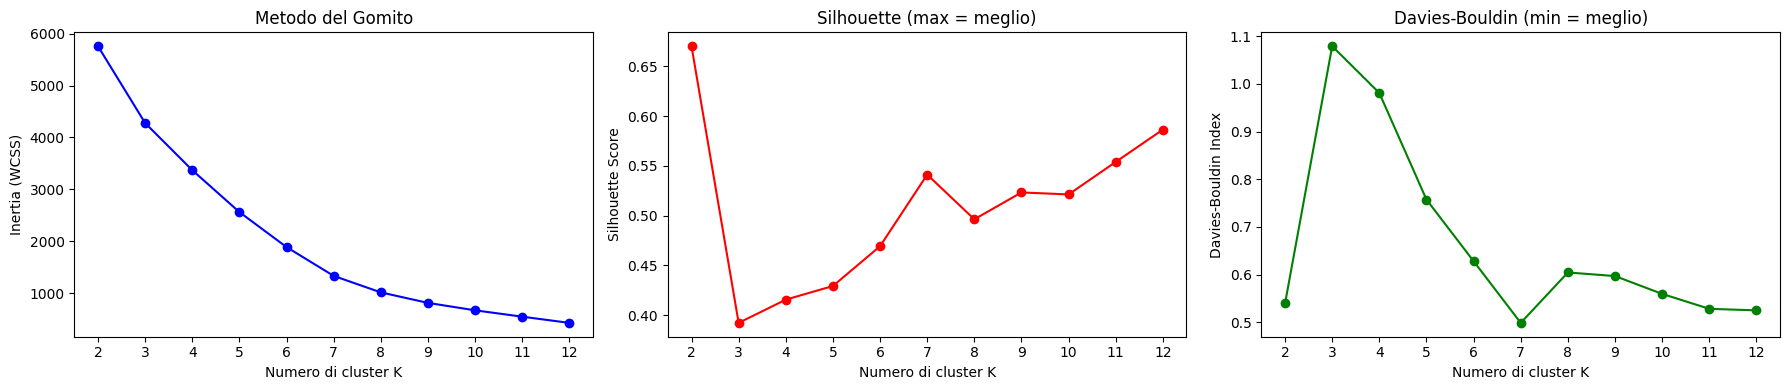

In [21]:
# 5.1.1 Valutazione geometrica su range di K
inertie = []
silhouette = []
davies_bouldin = []
K_range = range(2, 13)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(embeddings_5d)
    inertie.append(km.inertia_)
    silhouette.append(silhouette_score(embeddings_5d, labels))
    davies_bouldin.append(davies_bouldin_score(embeddings_5d, labels))

# Visualizzazione grafici di valutazione
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4))
ax1.plot(K_range, inertie, 'bo-')
ax1.set_xlabel('Numero di cluster K')
ax1.set_ylabel('Inertia (WCSS)')
ax1.set_title('Metodo del Gomito')
ax1.set_xticks(K_range)

ax2.plot(K_range, silhouette, 'ro-')
ax2.set_xlabel('Numero di cluster K')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette (max = meglio)')
ax2.set_xticks(K_range)

ax3.plot(K_range, davies_bouldin, 'go-')
ax3.set_xlabel('Numero di cluster K')
ax3.set_ylabel('Davies-Bouldin Index')
ax3.set_title('Davies-Bouldin (min = meglio)')
ax3.set_xticks(K_range)

plt.tight_layout()
plt.show()

### 5.2 Valutazione HDBSCAN (Clustering basato su densità)

Utilizziamo HDBSCAN come alternativa a K-Means per isolare cluster sferici irregolari ed escludere i punti anomali di "rumore" (indicati con -1).

In [24]:
# 5.2.1 Esecuzione HDBSCAN
import hdbscan

print("Calcolo dei cluster con HDBSCAN...")
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=15,
    min_samples=5,
    metric="manhattan"
)
hdbscan_labels = clusterer.fit_predict(embeddings_5d)
df["cluster_hdbscan"] = hdbscan_labels

n_clusters_hdb = len(set(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)
n_noise_hdb = list(hdbscan_labels).count(-1)

print(f"HDBSCAN ha individuato {n_clusters_hdb} cluster e ha classificato {n_noise_hdb} report come rumore (outlier).")

Calcolo dei cluster con HDBSCAN...
HDBSCAN ha individuato 10 cluster e ha classificato 58 report come rumore (outlier).


In [25]:
print(df["cluster_hdbscan"].value_counts())

cluster_hdbscan
 9    129
-1     58
 7     58
 2     51
 8     43
 0     34
 3     31
 6     30
 5     25
 4     20
 1     18
Name: count, dtype: int64


In [26]:
NUM_CLUSTERS = len(df['cluster_hdbscan'].unique())-1

for cluster_id in range(NUM_CLUSTERS):
    subset = df[df["cluster_hdbscan"] == cluster_id]
    print(f"\n=== CLUSTER {cluster_id} ({len(subset)} documenti) ===")
    print(subset[["paese", "inizio_periodo", "fine_periodo"]].to_string(index=False))


=== CLUSTER 0 (34 documenti) ===
   paese inizio_periodo fine_periodo
 Somalia       Apr 2025     Jun 2025
 Somalia       Jan 2024     Jun 2024
 Somalia       Jan 2019     Jun 2019
 Somalia       Jan 2021     Jun 2021
 Somalia       Jan 2023     Jun 2023
 Somalia       Jan 2013     Jun 2013
Ethiopia       Jul 2019     Jun 2020
 Somalia       Jun 2018     Dec 2018
 Somalia       Jan 2026     Jun 2026
 Somalia       Jan 2016     Jun 2016
 Somalia       Aug 2016     Dec 2016
Ethiopia       Jul 2020     Jun 2021
 Somalia       Jul 2013     Dec 2013
 Somalia       Mar 2023     Jun 2023
 Somalia       Aug 2023     Dec 2023
 Somalia       Jul 2021     Dec 2021
 Somalia       Jul 2019     Dec 2019
 Somalia       Jul 2024     Dec 2024
 Somalia       Jul 2014     Dec 2014
 Somalia       Jul 2017     Dec 2017
 Somalia       Jul 2012     Dec 2012
 Somalia       Jul 2022     Dec 2022
 Somalia       Mar 2022     Jun 2022
Ethiopia       May 2021     Sep 2021
 Somalia       Jul 2020     Dec 2020
 Som

## 6. Interpretazione, Lemmatizzazione e Validazione dei Cluster

### 6.1 Clustering Finale K-Means

In [27]:
# 6.1.1 K-Means definitivo
K_SCELTO = 7 # Imposta manualmente qui il K desiderato (es. K_SCELTO = 5)

km_final = KMeans(n_clusters=K_SCELTO, random_state=42, n_init=10)
df["cluster_kmeans"] = km_final.fit_predict(embeddings_5d)

# Trova l'indice del report più vicino al centroide per ciascun cluster
indici_piu_vicini, _ = pairwise_distances_argmin_min(km_final.cluster_centers_, embeddings_5d)

/opt/anaconda3/envs/master_3_10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/master_3_10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/master_3_10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [28]:
# ============================================================
# STEP 3: ESPLORA I CLUSTER
# ============================================================
for cluster_id in range(K_SCELTO):
    subset = df[df["cluster_kmeans"] == cluster_id]
    print(f"\n=== CLUSTER {cluster_id} ({len(subset)} documenti) ===")
    print(subset[["paese", "inizio_periodo", "fine_periodo"]].to_string(index=False))


=== CLUSTER 0 (34 documenti) ===
   paese inizio_periodo fine_periodo
 Somalia       Apr 2025     Jun 2025
 Somalia       Jan 2024     Jun 2024
 Somalia       Jan 2019     Jun 2019
 Somalia       Jan 2021     Jun 2021
 Somalia       Jan 2023     Jun 2023
 Somalia       Jan 2013     Jun 2013
Ethiopia       Jul 2019     Jun 2020
 Somalia       Jun 2018     Dec 2018
 Somalia       Jan 2026     Jun 2026
 Somalia       Jan 2016     Jun 2016
 Somalia       Aug 2016     Dec 2016
Ethiopia       Jul 2020     Jun 2021
 Somalia       Jul 2013     Dec 2013
 Somalia       Mar 2023     Jun 2023
 Somalia       Aug 2023     Dec 2023
 Somalia       Jul 2021     Dec 2021
 Somalia       Jul 2019     Dec 2019
 Somalia       Jul 2024     Dec 2024
 Somalia       Jul 2014     Dec 2014
 Somalia       Jul 2017     Dec 2017
 Somalia       Jul 2012     Dec 2012
 Somalia       Jul 2022     Dec 2022
 Somalia       Mar 2022     Jun 2022
Ethiopia       May 2021     Sep 2021
 Somalia       Jul 2020     Dec 2020
 Som

### 6.2 Parole Chiave con Lemmatizzazione e Rimozione dei Paesi (TF-IDF)

Per ottenere parole chiave semanticamente pulite, definiamo una pipeline di tokenizzazione personalizzata con **lemmatizzazione (NLTK WordNet Lemmatizer)** che riconduce le forme flesse alla loro radice (es. *conflicts* e *conflict* diventano entrambi *conflict*).

Rimuoveremo anche:
- Le stop words inglesi classiche.
- I nomi di tutti i Paesi inclusi nel dataset (ricavati automaticamente per evitare che i cluster contengano riferimenti geografici come parole chiave).
- Termini generici ricorrenti nei report (es. *people*, *report*, *situation*).

In [30]:
# 6.2.1 Inizializzazione lemmatizer NLTK e stop words
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Ricava i nomi unici dei paesi (in minuscolo) dal dataset per escluderli dalle parole chiave
nomi_paesi = set(df["paese"].str.lower().unique())
stop_words.update(nomi_paesi)

# Aggiungiamo termini generici dei report per isolare solo i driver delle crisi
termini_generici = [
    "report", "key", "results", "analysis", "ipc", "period", "country", "province",
    "provinces", "district", "districts", "million", "people", "population", "acute",
    "food", "security", "insecurity", "phase", "minimal", "stressed", "crisis",
    "emergency", "famine", "classified", "situation", "affected", "overall", "total",
    "compared", "projected", "period", "number"
]
stop_words.update(termini_generici)

# Funzione di tokenizzazione e lemmatizzazione per TfidfVectorizer
def tokenize_and_lemmatize(text):
    # Rimuove numeri e caratteri non alfabetici
    text_pulito = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = nltk.word_tokenize(text_pulito.lower())

    # Lemmatizza e filtra stop words e parole corte
    tokens_lemmatizzati = [
        lemmatizer.lemmatize(t) for t in tokens
        if t not in stop_words and len(t) > 2
    ]
    return tokens_lemmatizzati

# Funzione per estrarre le parole chiave TF-IDF per un cluster
def estrai_parole_chiave_cluster(df, cluster_col, cluster_id, top_n=10):
    text_data = df[df[cluster_col] == cluster_id]["testo"]

    # Utilizziamo l'analyzer customizzato che applica la nostra lemmatizzazione
    vectorizer = TfidfVectorizer(analyzer=tokenize_and_lemmatize, max_features=1000)
    tfidf_matrix = vectorizer.fit_transform(text_data)

    mean_tfidf = tfidf_matrix.mean(axis=0).A1
    terms = vectorizer.get_feature_names_out()

    top_indices = mean_tfidf.argsort()[::-1][:top_n]
    return [terms[i] for i in top_indices]

### 6.3 Analisi della Contingenza (Esclusione del Bias Geografico)

Per verificare se il clustering è guidato da driver semantici o se è semplicemente caduto in un bias geografico (raggruppando i report solo per Paese), calcoliamo:
1. **Tabella di Contingenza (Paese vs. Cluster)**: mostra quanti report di ciascun Paese cadono in ciascun cluster.
2. **Entropia Geografica del Cluster**: calcoliamo l'entropia della distribuzione dei Paesi per ciascun cluster. Valori di entropia più elevati indicano che il cluster aggrega report da molteplici Paesi differenti, confermando la bontà semantica del raggruppamento.

In [31]:
# 6.3.1 Calcolo Tabella di Contingenza ed Entropia
print("TABELLA DI CONTINGENZA (PAESE vs. CLUSTER K-MEANS):")
tabella_contingenza = pd.crosstab(df["paese"], df["cluster_kmeans"])
print(tabella_contingenza.to_string())

print(
    "\nENTROPIA GEOGRAFICA PER CIASCUN CLUSTER:\n"
    "(Valori alti = il cluster contiene molti paesi diversi, indicando coerenza semantica e basso bias geografico)"
)
for c_id in range(K_SCELTO):
    conteggio_paesi = df[df["cluster_kmeans"] == c_id]["paese"].value_counts()
    entropia_val = stats.entropy(conteggio_paesi)
    print(f"Cluster {c_id}: Entropia Geografica = {entropia_val:.2f} (Paesi unici: {len(conteggio_paesi)})")

TABELLA DI CONTINGENZA (PAESE vs. CLUSTER K-MEANS):
cluster_kmeans                     0   1   2  3   4   5   6
paese                                                      
Afghanistan                        0   0  17  0   0   4   0
Angola                             0   0   0  0   0   2   0
Bangladesh                         0   0   9  0   0   0   0
Burundi                            0   1   0  0   0  19   0
Cambodia                           0   0   0  0   0   1   0
Central African Republic           0   0   0  0   0  25   0
Democratic Republic of the Congo   0   0   0  0   0  20   0
Djibouti                           0   0   0  0   0  10   0
Dominican Republic                 0   2   0  0   0   1   0
Ecuador                            0   3   0  0   0   0   0
El Salvador                        0  15   0  2   0   0   0
Eswatini                           0   0   0  0   0  13   0
Ethiopia                           3   0   0  0   0   1   0
Gaza Strip                         0   0   0  0 

### 6.4 Esplorazione Qualitativa dei Cluster e dei Report Manifesto

In [32]:

# 6.4.1 Stampa dettagliata dei risultati
print(f"============================================================")
print(f"RISULTATI DEL CLUSTERING SEMANTICO CON INSTRUCTOR-LARGE")
print(f"============================================================")

for c_id in range(K_SCELTO):
    subset = df[df["cluster_kmeans"] == c_id]
    keywords = estrai_parole_chiave_cluster(df, "cluster_kmeans", c_id, top_n=10)

    idx_manifesto = indici_piu_vicini[c_id]
    manifesto_meta = df.iloc[idx_manifesto]

    print(f"\n\n👉 CLUSTER {c_id} ({len(subset)} report)")
    print(f"------------------------------------------------------------")
    print(f"📝 Parole Chiave Lemmatizzate (TF-IDF): {', '.join(keywords)}")
    print(f"📌 Report Manifesto: {manifesto_meta['paese']} ({manifesto_meta['periodo']})")
    print(f"📄 Estratto del Manifesto:\n{manifesto_meta['testo'][:500]}...")

RISULTATI DEL CLUSTERING SEMANTICO CON INSTRUCTOR-LARGE


👉 CLUSTER 0 (34 report)
------------------------------------------------------------
📝 Parole Chiave Lemmatizzate (TF-IDF): percent, area, humanitarian, expected, assistance, across, pastoral, rainfall, level, likely
📌 Report Manifesto: Somalia (Jul 2025 / Dec 2025)
📄 Estratto del Manifesto:
Poor rainfall, flooding and persistent conflict are driving 3.4 million people into high levels of acute food insecurity (IPC Phase 3 or above) across much of Somalia. Between July and September 2025, around 624,000 people (3 percent of the population) have been experiencing Emergency levels of acute food insecurity (IPC Phase 4), while more than 2.8 million people (15 percent of the population) have been experiencing IPC Phase 3 (Crisis).
In northern regions, poor rainfall and drought condition...


👉 CLUSTER 1 (61 report)
------------------------------------------------------------
📝 Parole Chiave Lemmatizzate (TF-IDF): percent, household,

In [33]:
# 6.4.1 Stampa dettagliata dei risultati
print(f"============================================================")
print(f"RISULTATI DEL CLUSTERING SEMANTICO CON INSTRUCTOR-LARGE")
print(f"============================================================")
print(NUM_CLUSTERS)
for c in range(NUM_CLUSTERS):
    subset = df[df["cluster_hdbscan"] == c]
    keywords = estrai_parole_chiave_cluster(df, "cluster_hdbscan", c, top_n=10)

    idx_manifesto = indici_piu_vicini[c]
    manifesto_meta = df.iloc[idx_manifesto]

    print(f"\n\n CLUSTER {c} ({len(subset)} report)")
    print(f"------------------------------------------------------------")
    print(f" Parole Chiave Lemmatizzate (TF-IDF): {', '.join(keywords)}")
    print(f" Report Manifesto: {manifesto_meta['paese']} ({manifesto_meta['periodo']})")
    print(f" Estratto del Manifesto:\n{manifesto_meta['testo'][:500]}...")

RISULTATI DEL CLUSTERING SEMANTICO CON INSTRUCTOR-LARGE
10


 CLUSTER 0 (34 report)
------------------------------------------------------------
 Parole Chiave Lemmatizzate (TF-IDF): percent, area, humanitarian, expected, assistance, across, pastoral, rainfall, level, likely
 Report Manifesto: Somalia (Jul 2025 / Dec 2025)
 Estratto del Manifesto:
Poor rainfall, flooding and persistent conflict are driving 3.4 million people into high levels of acute food insecurity (IPC Phase 3 or above) across much of Somalia. Between July and September 2025, around 624,000 people (3 percent of the population) have been experiencing Emergency levels of acute food insecurity (IPC Phase 4), while more than 2.8 million people (15 percent of the population) have been experiencing IPC Phase 3 (Crisis).
In northern regions, poor rainfall and drought condition...


 CLUSTER 1 (18 report)
------------------------------------------------------------
 Parole Chiave Lemmatizzate (TF-IDF): level, governorates, h

IndexError: index 7 is out of bounds for axis 0 with size 7

### 6.5 Validazione Coerenza con LLM-as-a-Judge (Opzionale)

Questa cella permette di usare l'API Mistral (o un altro LLM) per validare in modo intelligente la coerenza semantica di ciascun cluster, assegnare un nome descrittivo basato sulle parole chiave e sul testo manifesto e valutarne la coerenza semantica con un voto.

In [38]:
# 6.5.1 LLM-as-a-Judge
from mistralai.client import Mistral

EVALUATE_WITH_LLM = False  # Cambia in True se hai una chiave API e desideri eseguire la validazione

if EVALUATE_WITH_LLM:
    # Tentativo di recupero della chiave API dalle variabili d'ambiente
    api_key = os.environ.get("MISTRAL_API_KEY", "")
    if not api_key:
        # Prova la variabile speciale registrata
        api_key = os.environ.get("dryPUW6KqqVrbiAR8HrDoq3xnWpe6e3J", "")

    if api_key:
        try:
            client = Mistral(api_key=api_key)
            print("Client Mistral inizializzato. Avvio validazione cluster...")

            for c_id in range(K_SCELTO):
                keywords = estrai_parole_chiave_cluster(df, "cluster_kmeans", c_id, top_n=12)
                idx_manifesto = indici_piu_vicini[c_id]
                manifesto_meta = df.iloc[idx_manifesto]

                prompt = f"""
                Analizza questo cluster di report sull'insicurezza alimentare (IPC).
                I termini più rappresentativi (TF-IDF lemmatizzati) del cluster sono: {', '.join(keywords)}
                Il report manifesto (più vicino al centroide) è di {manifesto_meta['paese']} ({manifesto_meta['periodo']}) con il seguente testo:
                ---
                {manifesto_meta['testo'][:1000]}
                ---

                Fornisci una risposta strutturata in italiano:
                1. **Nome del Cluster**: Assegna un titolo descrittivo basato sul driver della crisi (es. \"Crisi da Siccità\", \"Crisi da Conflitto/Sfollamento\", \"Instabilità Economica\").
                2. **Descrizione Semantica**: Spiega quali driver e condizioni accomunano i report di questo cluster.
                3. **Punteggio di Coerenza Semantica**: Assegna un punteggio da 1 a 5 (5 = massima coerenza, 1 = cluster casuale) e motiva brevemente la valutazione.
                """

                response = client.chat.complete(
                    model="mistral-large-latest",
                    messages=[{"role": "user", "content": prompt}]
                )

                print(f"\\n============================================================")
                print(f"VALIDAZIONE LLM - CLUSTER {c_id}")
                print(f"============================================================")
                print(response.choices[0].message.content)

        except Exception as e:
            print(f"Errore durante la chiamata LLM: {e}")
    else:
        print("API Key non trovata. Inserisci la chiave API di Mistral per procedere.")
else:
    print("Validazione LLM disattivata. Imposta 'EVALUATE_WITH_LLM = True' per eseguirla.")

Validazione LLM disattivata. Imposta 'EVALUATE_WITH_LLM = True' per eseguirla.


## 7. Rappresentazione Grafica Interattiva (Plotly)

Creiamo uno scatter plot interattivo 2D proiettando le coordinate UMAP. Passando il puntatore sopra ciascun punto, verranno mostrati il Paese, il Periodo e le prime righe di anteprima del report.

In [35]:
# 7.1 Visualizzazione grafica interattiva
# Creiamo un'anteprima del testo per il tooltip (evitando ritorni a capo per un tooltip pulito)
df["anteprima_testo"] = df["testo"].apply(lambda x: x[:200].replace('\n', ' ') + "...")

# Convertiamo la categoria del cluster in stringa per usare colori distinti
df["cluster_kmeans_str"] = df["cluster_kmeans"].astype(str)

fig = px.scatter(
    df,
    x="x",
    y="y",
    color="cluster_kmeans_str",
    hover_data={
        "paese": True,
        "periodo": True,
        "cluster_kmeans_str": True,
        "anteprima_testo": False,
        "x": False,
        "y": False
    },
    title=f"Clustering Semantico dei Report IPC (K-Means K={K_SCELTO})",
    labels={"cluster_kmeans_str": "Cluster"},
    category_orders={"cluster_kmeans_str": sorted(df["cluster_kmeans_str"].unique())},
    width=1100,
    height=750
)

# Miglioramento stilistico e salvataggio
fig.update_traces(marker=dict(size=8, opacity=0.8, line=dict(width=0.5, color='DarkSlateGrey')))
fig.update_layout(
    legend_title_text="Cluster",
    plot_bgcolor="#F8F9FA",
    paper_bgcolor="white",
    xaxis=dict(showgrid=True, gridcolor="#EAEAEA", zeroline=False),
    yaxis=dict(showgrid=True, gridcolor="#EAEAEA", zeroline=False)
)

# Salva il grafico interattivo in HTML per aprirlo comodamente nel browser locale
fig.write_html(os.path.join(DRIVE_PATH, "mappa_cluster_interattiva.html"))
print(f"Grafico salvato su Drive: mappa_cluster_interattiva.html")

# Rendering del grafico all'interno del notebook Colab
fig.show(renderer="browser")

Grafico salvato su Drive: mappa_cluster_interattiva.html


In [36]:
import plotly.express as px
import pandas as pd

# 1. Lista dei paesi univoci estratti dal Cluster 9
paesi_cluster_9 = [
    "Mozambique", "United Republic of Tanzania", "Zimbabwe", "Malawi",
    "Madagascar", "Central African Republic", "Eswatini", "Haiti",
    "Djibouti", "Angola", "Burundi", "Namibia", "Lesotho", "Cambodia",
    "South Africa", "Zambia", "Timor-Leste", "Somalia"
]

# 2. Creazione di un DataFrame dedicato per la visualizzazione
df_mappa = pd.DataFrame({
    "Country": paesi_cluster_9,
    "Cluster": ["Cluster 9"] * len(paesi_cluster_9)
})

# 3. Generazione della mappa coropletica interattiva
fig = px.choropleth(
    df_mappa,
    locations="Country",
    locationmode="country names",
    color="Cluster",
    color_discrete_sequence=["#ef553b"], # Colore rosso/arancio per evidenziare gli stati
    title="Distribuzione Geografica: Cluster 9",
    hover_name="Country"
)

# 4. Ottimizzazione del layout grafico
fig.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='natural earth', # Proiezione cartografica più realistica
        showland=True,
        landcolor="lightgray"
    ),
    margin={"r":0, "t":50, "l":0, "b":0}
)

# 5. Rendering
fig.show(renderer="browser")

/var/folders/rw/yfzdsbw537g9qcgj4vc9jfcr0000gn/T/ipykernel_22736/367933091.py:19: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


In [ ]:
import plotly.express as px
import pandas as pd

# 1. Lista dei paesi univoci estratti dal Cluster 9
paesi_cluster_9 = [
    "Mozambique", "United Republic of Tanzania", "Zimbabwe", "Malawi",
    "Madagascar", "Central African Republic", "Eswatini", "Haiti",
    "Djibouti", "Angola", "Burundi", "Namibia", "Lesotho", "Cambodia",
    "South Africa", "Zambia", "Timor-Leste", "Somalia"
]

# 2. Creazione di un DataFrame dedicato per la visualizzazione
df_mappa = pd.DataFrame({
    "Country": paesi_cluster_9,
    "Cluster": ["Cluster 9"] * len(paesi_cluster_9)
})

# 3. Generazione della mappa coropletica interattiva
fig = px.choropleth(
    df_mappa,
    locations="Country",
    locationmode="country names",
    color="Cluster",
    color_discrete_sequence=["#ef553b"], # Colore rosso/arancio per evidenziare gli stati
    title="Distribuzione Geografica: Cluster 9",
    hover_name="Country"
)

# 4. Ottimizzazione del layout grafico
fig.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='natural earth', # Proiezione cartografica più realistica
        showland=True,
        landcolor="lightgray"
    ),
    margin={"r":0, "t":50, "l":0, "b":0}
)

# 5. Rendering
fig.show()

In [29]:
# 7.1 Visualizzazione grafica interattiva

# Convertiamo la categoria del cluster in stringa per usare colori distinti
df["cluster_hdbscan_str"] = df["cluster_hdbscan"].astype(str)

fig = px.scatter(
    df,
    x="x",
    y="y",
    color="cluster_hdbscan_str",
    hover_data={
        "paese": True,
        "periodo": True,
        "cluster_hdbscan_str": True,
        "anteprima_testo": False,
        "x": False,
        "y": False
    },
    title=f"Clustering Semantico dei Report IPC (HDBSCAN)",
    labels={"cluster_hdbscan_str": "Cluster"},
    category_orders={"cluster_hdbscan_str": sorted(df["cluster_hdbscan_str"].unique())},
    width=1100,
    height=750
)

# Miglioramento stilistico e salvataggio
fig.update_traces(marker=dict(size=8, opacity=0.8, line=dict(width=0.5, color='DarkSlateGrey')))
fig.update_layout(
    legend_title_text="Cluster",
    plot_bgcolor="#F8F9FA",
    paper_bgcolor="white",
    xaxis=dict(showgrid=True, gridcolor="#EAEAEA", zeroline=False),
    yaxis=dict(showgrid=True, gridcolor="#EAEAEA", zeroline=False)
)

# Salva il grafico interattivo in HTML per aprirlo comodamente nel browser locale
fig.write_html(os.path.join(DRIVE_PATH, "mappa_cluster_interattiva.html"))
print(f"Grafico salvato su Drive: mappa_cluster_interattiva.html")

# Rendering del grafico all'interno del notebook Colab
fig.show()

ValueError: Value of 'hover_data_3' is not the name of a column in 'data_frame'. Expected one of ['paese', 'periodo', 'inizio_periodo', 'fine_periodo', 'nome_file', 'testo', 'x', 'y', 'cluster_hdbscan', 'cluster_kmeans', 'cluster_hdbscan_str'] but received: anteprima_testo

In [35]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# --- FILTRO PER HDBSCAN (Escludiamo gli outlier -1 dalle metriche di distanza) ---
df_filtered = df[df["cluster_hdbscan"] != -1]
embeddings_filtered = embeddings_5d[df["cluster_hdbscan"] != -1]

# --- CALCOLO METRICHE K-MEANS ---
km_sil = silhouette_score(embeddings_5d, df["cluster_kmeans"])
km_ch = calinski_harabasz_score(embeddings_5d, df["cluster_kmeans"])
km_db = davies_bouldin_score(embeddings_5d, df["cluster_kmeans"])

# --- CALCOLO METRICHE HDBSCAN ---
hdb_sil = silhouette_score(embeddings_filtered, df_filtered["cluster_hdbscan"])
hdb_ch = calinski_harabasz_score(embeddings_filtered, df_filtered["cluster_hdbscan"])
hdb_db = davies_bouldin_score(embeddings_filtered, df_filtered["cluster_hdbscan"])

# --- COSTRUZIONE TABELLA DI CONFRONTO ---
confronto_data = {
    "Metrica": [
        "Numero di Cluster trovati",
        "Percentuale Rumore / Outliers",
        "Silhouette Score (Più alto = meglio)",
        "Calinski-Harabasz Index (Più alto = meglio)",
        "Davies-Bouldin Index (Più basso = meglio)"
    ],
    "K-Means": [
        df["cluster_kmeans"].nunique(),
        "0.0% (Forza tutti i punti)",
        f"{km_sil:.3f}",
        f"{km_ch:.1f}",
        f"{km_db:.3f}"
    ],
    "HDBSCAN": [
        df_filtered["cluster_hdbscan"].nunique(),
        f"{(df['cluster_hdbscan'] == -1).sum() / len(df) * 100:.1f}%",
        f"{hdb_sil:.3f}",
        f"{hdb_ch:.1f}",
        f"{hdb_db:.3f}"
    ]
}

df_confronto = pd.DataFrame(confronto_data)
print("\n=== TABELLA COMPARATIVA DEL CLUSTERING A 5D ===")
display(df_confronto)


=== TABELLA COMPARATIVA DEL CLUSTERING A 5D ===


,Metrica,K-Means,HDBSCAN
0,Numero di Cluster trovati,8,15
1,Percentuale Rumore / Outliers,0.0% (Forza tutti i punti),13.1%
2,Silhouette Score (Più alto = meglio),0.639,0.647
3,Calinski-Harabasz Index (Più alto = meglio),923.4,1675.7
4,Davies-Bouldin Index (Più basso = meglio),0.358,0.523


In [39]:
# 1. DEFINIZIONE DELLE GRIGLIE (Popolate correttamente per il tuo dataset)
grid_min_cluster = [5, 8, 10, 15]
grid_min_samples = [1, 2, 3, 5]
grid_metrics = ['euclidean', 'manhattan']

risultati = []

print("Esecuzione dell'ottimizzazione in corso...")

for m_cluster in grid_min_cluster:
    for m_samples in grid_min_samples:
        for metrica in grid_metrics:

            # CORREZIONE: gen_min_span_tree=True è obbligatorio per calcolare la stabilità
            clusterer = hdbscan.HDBSCAN(
                min_cluster_size=m_cluster,
                min_samples=m_samples,
                metric=metrica,
                gen_min_span_tree=True
            )
            labels = clusterer.fit_predict(embeddings_5d)

            # Calcola il numero di cluster (escludendo il rumore -1)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

            # Calcola la percentuale di rumore
            percentuale_rumore = (labels == -1).sum() / len(labels) * 100

            # Calcola le metriche solo se ci sono almeno 2 cluster reali
            if n_clusters >= 2 and percentuale_rumore < 90:
                mask = labels != -1
                sil_score = silhouette_score(embeddings_5d[mask], labels[mask])

                # Ora questo attributo non fallirà più
                dbcv_approx = clusterer.relative_validity_
            else:
                sil_score = np.nan
                dbcv_approx = np.nan

            risultati.append({
                "min_cluster_size": m_cluster,
                "min_samples": m_samples,
                "metric": metrica,
                "Num_Cluster": n_clusters,
                "Perc_Rumore_%": round(percentuale_rumore, 1),
                "Silhouette_Pura": round(sil_score, 3) if pd.notnull(sil_score) else np.nan,
                "Stabilita_Media": round(dbcv_approx, 3) if pd.notnull(dbcv_approx) else np.nan
            })

# Converte in DataFrame e ordina per Silhouette più alta
df_tuning = pd.DataFrame(risultati).dropna()
df_tuning = df_tuning.sort_values(by="Silhouette_Pura", ascending=False).reset_index(drop=True)

print("\n=== TOP 10 CONFIGURAZIONI MIGLIORI ===")
display(df_tuning.head(50))

Esecuzione dell'ottimizzazione in corso...

=== TOP 10 CONFIGURAZIONI MIGLIORI ===


,min_cluster_size,min_samples,metric,Num_Cluster,Perc_Rumore_%,Silhouette_Pura,Stabilita_Media
0,5,3,manhattan,41,10.5,0.695,0.360
1,5,5,manhattan,33,13.5,0.691,0.283
2,5,5,euclidean,33,11.7,0.690,0.416
3,5,2,euclidean,43,11.7,0.681,0.419
4,5,2,manhattan,44,9.5,0.676,0.406
5,5,3,euclidean,40,7.4,0.670,0.342
6,5,1,manhattan,44,9.7,0.668,0.449
7,15,3,manhattan,15,13.9,0.662,0.430
8,15,2,manhattan,15,12.5,0.658,0.346
9,15,1,manhattan,15,12.3,0.656,0.356
